In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from transformers import AutoProcessor, MusicgenForConditionalGeneration
import utils
import random

# 1. Load the model and processor
# (musicgen-small works great for extracting attention weights without using too much VRAM)
processor = AutoProcessor.from_pretrained("facebook/musicgen-small")
model = MusicgenForConditionalGeneration.from_pretrained(
    "facebook/musicgen-small",
    attn_implementation="eager"
    )
model.eval()
# 2. Load and preprocess your song (or an audio snippet)
# MusicGen expects a sampling rate of 32,000 Hz
audio_paths = [
    "../music-clips/classical_8.wav",
    "../music-clips/classical_1.wav",
    "../music-clips/classical_2.wav",
    "../music-clips/classical_6.wav",
    "../music-clips/electronic_1.wav",
    "../music-clips/electronic_10.wav",
    "../music-clips/electronic_14.wav",
    "../music-clips/electronic_3.wav",
    ]
inputs_dict = utils.load_process_bulk_audio(audio_paths, processor)

# 4. Encode audio and get text representations
with torch.no_grad():
    attentions_dict = {}
    decoder_input_dict = {}
    for path, input in inputs_dict.items():
    # Convert audio to EnCodec tokens (audio codes)
        audio_features = input["input_values"]
        decoder_input_ids = model.audio_encoder.encode(audio_features).audio_codes
        decoder_input_dict[path] = decoder_input_ids
        # dummy conditioning: shape must match what the decoder expects
        batch_size = decoder_input_ids.shape[0]
        dummy_encoder_hidden_states = torch.zeros(
            batch_size,
            1,
            1024,  # musicgen-small hidden size
            device=decoder_input_ids.device
        )
        # We must pass the text encoder's hidden states as cross-attention conditioning
        decoder_outputs = model.decoder(
            input_ids=decoder_input_ids,
            encoder_hidden_states=dummy_encoder_hidden_states,  # Map the correct 1024 shape here        output_attentions=True,
            output_attentions=True,
            return_dict=True
        )

        self_attentions = decoder_outputs.attentions
        attentions_dict[path] = self_attentions

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

In [ ]:
mad_dict = {}
for path, attn in attentions_dict.items():
    seq_length = decoder_input_dict.get(path).shape[-1]
    print(path, seq_length)
    mean_distances_seconds = utils.compute_mad_by_layer(attn, seq_length)
    mad_dict[path] = mean_distances_seconds

../music-clips/classical_8.wav 750
../music-clips/classical_1.wav 750
../music-clips/classical_2.wav 750
../music-clips/classical_6.wav 750
../music-clips/electronic_1.wav 750
../music-clips/electronic_10.wav 750
../music-clips/electronic_14.wav 750
../music-clips/electronic_3.wav 750


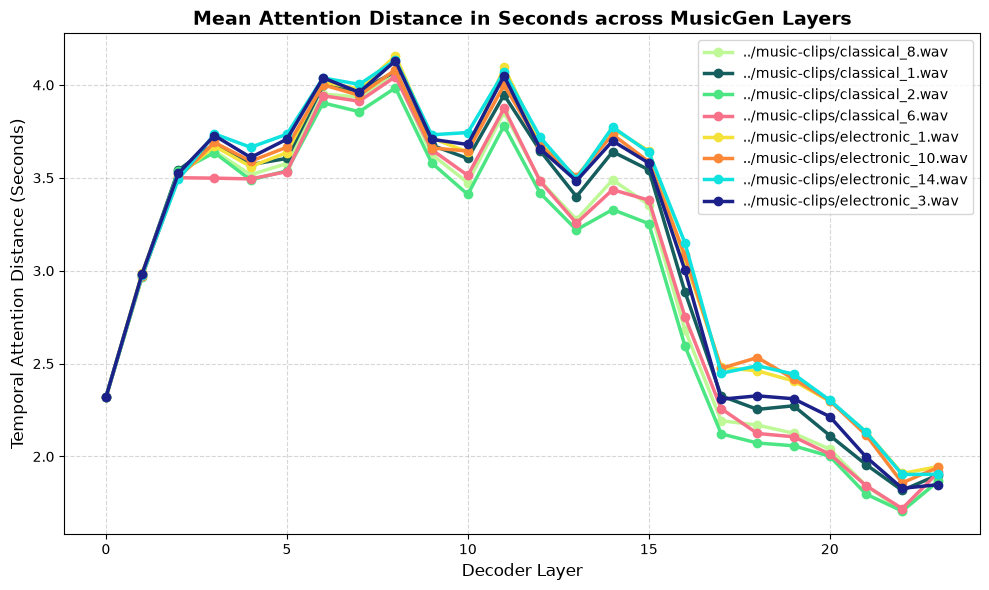

In [ ]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(attentions_dict.get(path))
    layer_averages_sec = np.mean(mads, axis=1)
    plt.plot(range(num_layers), layer_averages_sec, color=random_hex, linewidth=2.5, marker='o', label=path)

plt.title("Mean Attention Distance in Seconds across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Decoder Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Seconds)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()